
******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     2769
Number of nonzeros in inequality constraint Jacobian.:      500
Number of nonzeros in Lagrangian Hessian.............:     2000

Total number of variables............................:      501
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        1
                     variables with only upper bounds:        0
Total number of equality constraints.................:      352
Total number of inequality c

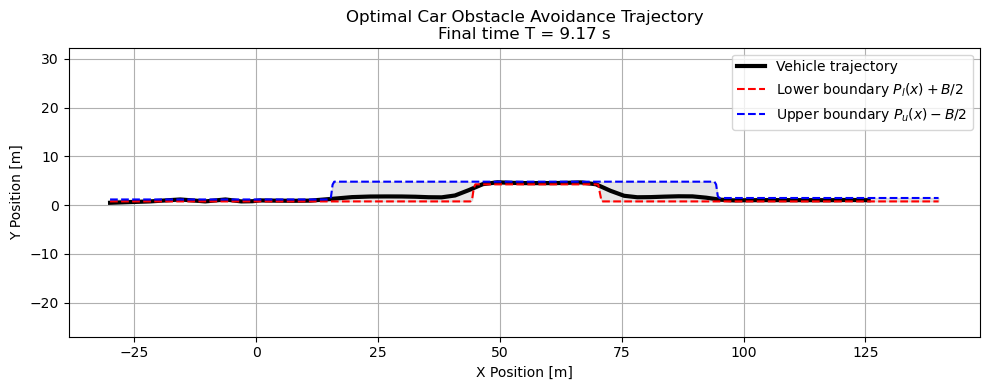

In [1]:
# ===== main.py (final version) =====
import numpy as np
import casadi as ca
from ocp_formulation import setup_ocp
from utils import unpack_solution, plot_trajectory

# Problem parameters
gear = 2           # selected gear for entire trajectory
dt = 0.1           # initial guess for time step
N = 50             # number of shooting intervals
use_soft_track = False  # use hard constraints for strict satisfaction

# Setup and solve the OCP
solver, nlp, integrator, lbg, ubg = setup_ocp(gear, dt, N, use_soft_track=use_soft_track)

# Dimensions
nx, nu = 7, 3
w0 = np.zeros(nlp['x'].shape[0])

# Initial state guess
w0[0:nx] = [-30, 0, 10, 0, 0, 0, 0]

w0[-1] = 7.0  # Initial guess for final time T

# State trajectory initial guess
for i in range(N):
    ratio = i / (N - 1)
    x_guess = -30 + (130 - (-30)) * ratio
    if x_guess < 44:
        y_guess = 0
    elif x_guess < 70:
        y_guess = 4
    else:
        y_guess = 0
    w0[i * nx : (i + 1) * nx] = [x_guess, y_guess, 10, 0, 0, 0, 0]

# Control trajectory initial guess
for i in range(N):
    ctrl_base = nx * N + i * nu
    if i < N // 3:
        w0[ctrl_base] = 0.2
    elif i < 2 * N // 3:
        w0[ctrl_base] = 0.0
    else:
        w0[ctrl_base] = -0.2
    w0[ctrl_base + 1] = 0.0
    w0[ctrl_base + 2] = 0.5

# Bounds on decision variables
lbw = [-ca.inf] * (nlp['x'].shape[0] - 1) + [1.0]
ubw = [ca.inf] * (nlp['x'].shape[0] - 1) + [20.0]


# Solve NLP
solution = solver(x0=w0, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg)

# Unpack and visualize solution
X_opt, U_opt, T_opt = unpack_solution(solution['x'], N, nx=nx, nu=nu)
print("Solved:", solver.stats()['success'])
print("Final time T_opt:", T_opt)
print("Final position X:", X_opt[-1, 0])

# Plot the trajectory
plot_trajectory(X_opt, T_opt, track=True, title='Optimal Car Obstacle Avoidance Trajectory')


In [4]:
print("T_opt:", T_opt)
print("实际轨迹耗时 ≈", T_opt)
print("轨迹每步时间间隔应为：", T_opt / N)

T_opt: 9.172384798667187
实际轨迹耗时 ≈ 9.172384798667187
轨迹每步时间间隔应为： 0.18344769597334373
